#Importing Libraries


In [109]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import (train_test_split,StratifiedKFold,
cross_val_score,RandomizedSearchCV)
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier

from lightgbm import LGBMClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,
    roc_auc_score,confusion_matrix,classification_report,roc_curve)

from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings("ignore")

#Loading Dataset

In [110]:
df = pd.read_excel('/content/Telco_customer_churn.xlsx')

df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [111]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [112]:
pd.set_option('display.max_columns', None)

In [113]:
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,No,Yes,Yes,28,Yes,Yes,Fiber optic,No,No,Yes,Yes,Yes,Yes,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,No,No,Yes,49,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


#Data Understanding

In [114]:
print("Shape of dataset -",df.shape)

Shape of dataset - (7043, 33)


In [115]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [116]:
df.describe()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Monthly Charges,Churn Value,Churn Score,CLTV
count,7043.0,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,1.0,93521.964646,36.282441,-119.798880,32.371149,64.761692,0.265370,58.699418,4400.295755
std,0.0,1865.794555,2.455723,2.157889,24.559481,30.090047,0.441561,21.525131,1183.057152
min,1.0,90001.000000,32.555828,-124.301372,0.000000,18.250000,0.000000,5.000000,2003.000000
25%,1.0,92102.000000,34.030915,-121.815412,9.000000,35.500000,0.000000,40.000000,3469.000000
50%,1.0,93552.000000,36.391777,-119.730885,29.000000,70.350000,0.000000,61.000000,4527.000000
75%,1.0,95351.000000,38.224869,-118.043237,55.000000,89.850000,1.000000,75.000000,5380.500000
max,1.0,96161.000000,41.962127,-114.192901,72.000000,118.750000,1.000000,100.000000,6500.000000


#Missing Values Analysis

In [117]:
missing_values = df.isnull().sum()

missing_values = missing_values[missing_values > 0]

missing_values.sort_values(ascending=False)

,0
Churn Reason,5174


#Duplicate Records

In [118]:
print("Duplicate Records:", df.duplicated().sum())

Duplicate Records: 0


In [119]:
#Convert Total Charges

df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

df["Total Charges"] = df[
    "Total Charges"
].fillna(0)

# Exploratory Data Analysis (EDA)


###Churn Distribution

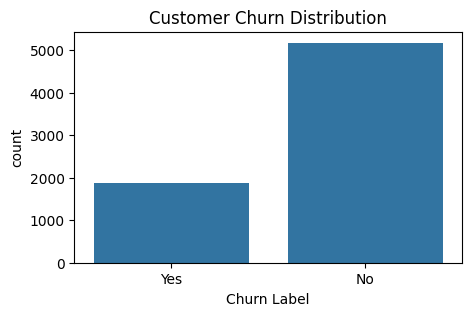

In [120]:

plt.figure(figsize=(5,3))

sns.countplot(x="Churn Label",data=df)

plt.title("Customer Churn Distribution")
plt.show()

##Churn Percentage Distribution

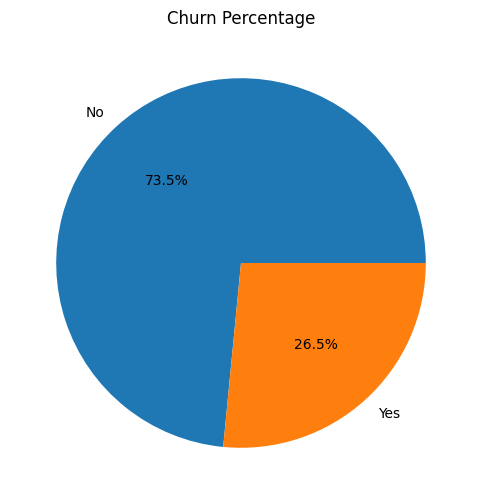

In [121]:
plt.figure(figsize=(6,6))

df["Churn Label"].value_counts().plot(kind="pie",
  autopct="%1.1f%%"
)

plt.ylabel("")
plt.title("Churn Percentage")
plt.show()

In [122]:
num_cols = ["Tenure Months","Monthly Charges","Total Charges","CLTV"]
df[num_cols].describe()

,Tenure Months,Monthly Charges,Total Charges,CLTV
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,32.371149,64.761692,2279.734304,4400.295755
std,24.559481,30.090047,2266.794470,1183.057152
min,0.000000,18.250000,0.000000,2003.000000
25%,9.000000,35.500000,398.550000,3469.000000
50%,29.000000,70.350000,1394.550000,4527.000000
75%,55.000000,89.850000,3786.600000,5380.500000
max,72.000000,118.750000,8684.800000,6500.000000


Tenure Months vs Churn

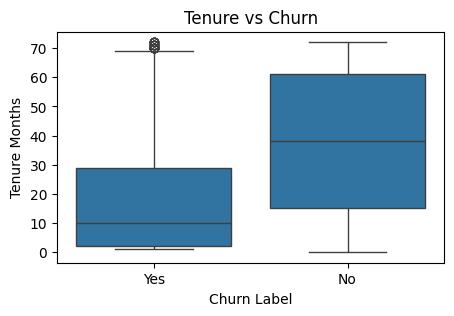

In [123]:
plt.figure(figsize=(5,3))

sns.boxplot(x="Churn Label",y="Tenure Months",data=df)

plt.title("Tenure vs Churn")
plt.show()

### Insight
Customers with lower tenure are more likely to churn.

Long-term customers tend to remain loyal and have a lower churn rate.

Monthly Charges Analysis

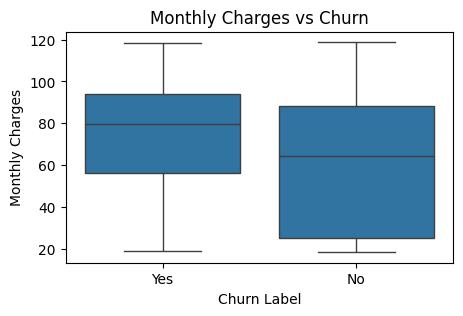

In [124]:
plt.figure(figsize=(5,3))

sns.boxplot(x="Churn Label",y="Monthly Charges",data=df)

plt.title("Monthly Charges vs Churn")
plt.show()

## Contract Type vs Churn

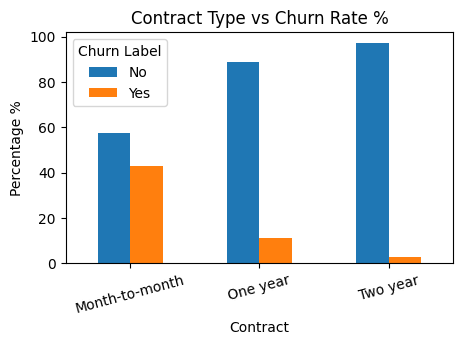

In [125]:
contract_churn = df.groupby('Contract')['Churn Label'].value_counts(normalize=True).mul(100).unstack()
contract_churn.plot(kind='bar', figsize=(5,3))
plt.title('Contract Type vs Churn Rate %')
plt.ylabel('Percentage %')
plt.xticks(rotation=15)
plt.show()

##Internet Service vs Churn

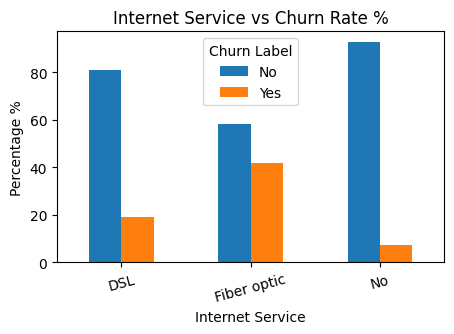

In [126]:
internet_churn = df.groupby('Internet Service')['Churn Label'].value_counts(normalize=True).mul(100).unstack()
internet_churn.plot(kind='bar', figsize=(5,3))
plt.title('Internet Service vs Churn Rate %')
plt.ylabel('Percentage %')
plt.xticks(rotation=15)
plt.show()

### Key Insight
1.Customers with lower tenure are more likely to churn.

Long-term customers tend to remain loyal and have a lower churn rate.

2.Customers paying higher monthly charges show a greater tendency to churn.

3.Month-to-month contracts exhibit the highest churn rates, while long-term contracts significantly reduce churn.


4.Customers who chose Fibre Optics has more churn rate when compared with other services

#correlation Heatmap

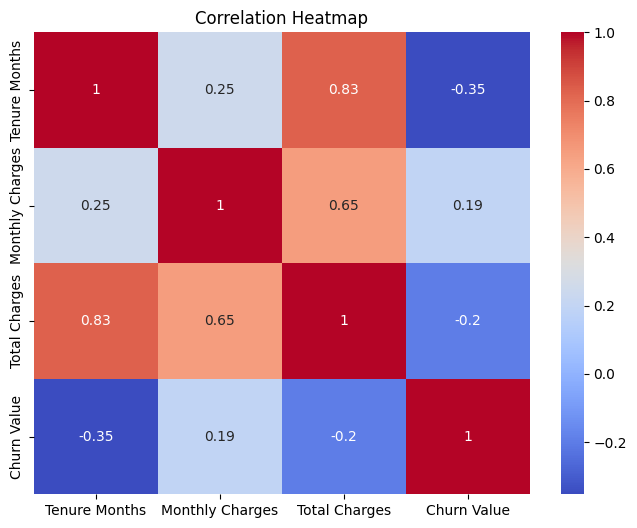

In [127]:
numeric_cols = [
    "Tenure Months",
    "Monthly Charges",
    "Total Charges",
    "Churn Value"
]

plt.figure(figsize=(8,6))

sns.heatmap(
    df[numeric_cols].corr(),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

##Data Cleaning

In [128]:
data = df.copy()

In [129]:
drop_cols = ["CustomerID","Count","Country","State","City","Zip Code","Lat Long",
    "Latitude","Longitude","Churn Value","Churn Score", "CLTV", "Churn Reason"]

data.drop(columns=drop_cols,inplace=True)

### Features Removed

The following columns were removed because:

- CustomerID -- Unique identifier
- Country, State, City -- High cardinality location variables
- Latitude, Longitude -- Not relevant for churn prediction
- Churn Score, CLTV, Churn Reason -- Potential target leakage

#Feature Engineering

In [130]:
# Tenure Group

data["Tenure Group"] = pd.cut(data["Tenure Months"],bins=[-1, 12, 24, 48, 72],
                      labels=["New","Growing","Established","Loyal"])





In [131]:
# Service Count

service_cols = ["Phone Service","Multiple Lines","Online Security",
    "Online Backup","Device Protection","Tech Support","Streaming TV",
                "Streaming Movies"]

data["Service Count"] = (data[service_cols].eq("Yes").sum(axis=1))


In [132]:
# Auto Payment

data["Auto Payment"] = (data["Payment Method"]
    .str.contains("automatic",case=False).astype(int))


### Features Created

1. Tenure Group -- Customer lifecycle stage
2. Service Count -- Number of subscribed services
3. Auto Payment -- Whether the customer uses automatic payment methods

##Label Encoding for Target

The target variable is converted into binary format:

- Yes -- 1 (Churn)
- No --- 0 (Stay)

In [133]:
data["Churn Label"] = data["Churn Label"].map({"Yes":1,"No":0})

##Features and Target

In [134]:
X = data.drop("Churn Label",axis=1)

y = data["Churn Label"]

In [135]:
print(y.value_counts())

print( y.value_counts(normalize=True)*100)

Churn Label
0    5174
1    1869
Name: count, dtype: int64
Churn Label
0    73.463013
1    26.536987
Name: proportion, dtype: float64


### Observation:

The dataset is imbalanced, with non-churn customers significantly outnumbering churn customers.

SMOTE will be applied to address class imbalance.

##Train Test Split

In [136]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,
                                  random_state=42,stratify=y)

In [137]:
#Replace No Internet Service
replace_dict = {"No internet service":"No", "No phone service":"No"}

X_train = X_train.replace(replace_dict)

X_test = X_test.replace(replace_dict)

##One-Hot Encoding

In [138]:
X_train = pd.get_dummies(X_train, drop_first=True)
X_test = pd.get_dummies(X_test, drop_first=True)

X_train, X_test = X_train.align(X_test,join="left",axis=1,fill_value=0)


#Convert Boolean Columns

In [139]:
X_train = X_train.astype(int, errors="ignore")

X_test = X_test.astype(int, errors="ignore")

##Scaling

In [140]:
num_cols = ["Tenure Months","Monthly Charges","Total Charges","Service Count"]

scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])

X_test[num_cols] = scaler.transform(X_test[num_cols])

#Cross Validation

In [141]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)


In [142]:
models = {

    "Random Forest":
        RandomForestClassifier(random_state=42, class_weight="balanced"),
    "LightGBM":
        LGBMClassifier(random_state=42, class_weight="balanced", verbose=-1)
}


In [143]:
results = []

for name, model in models.items():
    score = cross_val_score(model,X_train,y_train,cv=skf,scoring="roc_auc"
    ).mean()

    results.append([name, score])

results = pd.DataFrame(results, columns=["Model","ROC_AUC"])
results


,Model,ROC_AUC
0,Random Forest,0.836381
1,LightGBM,0.854008


### Observation

Among the baseline models, LightGBM achieved the highest ROC-AUC score.

Since both models performed well, hyperparameter tuning need to be applied to optimize their performance before final model selection.

#Smote

In [144]:
#Handling Class Imbalanve

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train,y_train)

print(X_train_smote.shape)
print(y_train_smote.value_counts())

(8278, 28)
Churn Label
0    4139
1    4139
Name: count, dtype: int64


#  LightGBM Hyperparameter Tuning

In [145]:
lgbm = LGBMClassifier(random_state=42, verbose=-1)

lgbm_param_grid = {
    "n_estimators":[100,200,300],
    "learning_rate":[0.01,0.05,0.1],
    "max_depth":[3,5,7],
    "num_leaves":[15,31,50]
}

lgbm_search = RandomizedSearchCV(
    estimator=lgbm,
    param_distributions=lgbm_param_grid,
    n_iter=10,
    cv=skf,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)


In [146]:
lgbm_search.fit(X_train_smote, y_train_smote)

best_lgbm = lgbm_search.best_estimator_


# Random Forest Tuning

In [147]:
rf = RandomForestClassifier(random_state=42)

rf_param_grid = {
    "n_estimators":[100,200,300,500],
    "max_depth":[5,10,20,None],
    "min_samples_split":[2,5,10],
    "min_samples_leaf":[1,2,4],
    "max_features":["sqrt","log2"]
}

rf_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=rf_param_grid,
    n_iter=20,
    cv=skf,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)


In [148]:
rf_search.fit(X_train_smote, y_train_smote)

rf_final = rf_search.best_estimator_



# Predictions

In [149]:
rf_pred = rf_final.predict(X_test)
rf_prob = rf_final.predict_proba(X_test)[:,1]

lgbm_pred = best_lgbm.predict(X_test)
lgbm_prob = best_lgbm.predict_proba(X_test)[:,1]


# Comparison

In [150]:
comparison = pd.DataFrame({
    "Model":["Random Forest","LightGBM"],
    "F1 Score":[
        f1_score(y_test, rf_pred),
        f1_score(y_test, lgbm_pred)
    ],
    "ROC AUC":[
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, lgbm_prob)
    ]
})


###Final Model Comparison

The tuned models are evaluated on unseen test data.

F1 Score is used as the primary selection metric because churn prediction requires balancing precision and recall.

In [151]:
print("Model Comparison")
print(comparison)

best_model_name = comparison.sort_values(
    by=["F1 Score","ROC AUC"],
    ascending=False
).iloc[0]["Model"]

print("\nSelected Best Model:", best_model_name)

if best_model_name == "Random Forest":
    final_model = rf_final
    y_pred = rf_pred
    y_prob = rf_prob
else:
    final_model = best_lgbm
    y_pred = lgbm_pred
    y_prob = lgbm_prob

Model Comparison
           Model  F1 Score   ROC AUC
0  Random Forest  0.607721  0.829804
1       LightGBM  0.606289  0.827447

Selected Best Model: Random Forest


### Observation

Random Forest achieved the highest F1 Score and was selected as the final model.

ROC-AUC was used as a secondary metric when comparing overall discrimination ability.

# Evaluation

In [152]:
print("Accuracy:", accuracy_score(y_test,y_pred))
print("Precision:", precision_score(y_test,y_pred))
print("Recall:", recall_score(y_test,y_pred))
print("F1:", f1_score(y_test,y_pred))
print("ROC AUC:", roc_auc_score(y_test,y_prob))


Accuracy: 0.7764371894960965
Precision: 0.5687645687645687
Recall: 0.6524064171122995
F1: 0.6077210460772104
ROC AUC: 0.8298044382443359


In [153]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.82      0.84      1035
           1       0.57      0.65      0.61       374

    accuracy                           0.78      1409
   macro avg       0.72      0.74      0.73      1409
weighted avg       0.79      0.78      0.78      1409



In [154]:
importance = pd.DataFrame({"Feature":X_train.columns,
                           "Importance":final_model.feature_importances_})

In [155]:
importance = importance.sort_values(by="Importance",ascending=False)

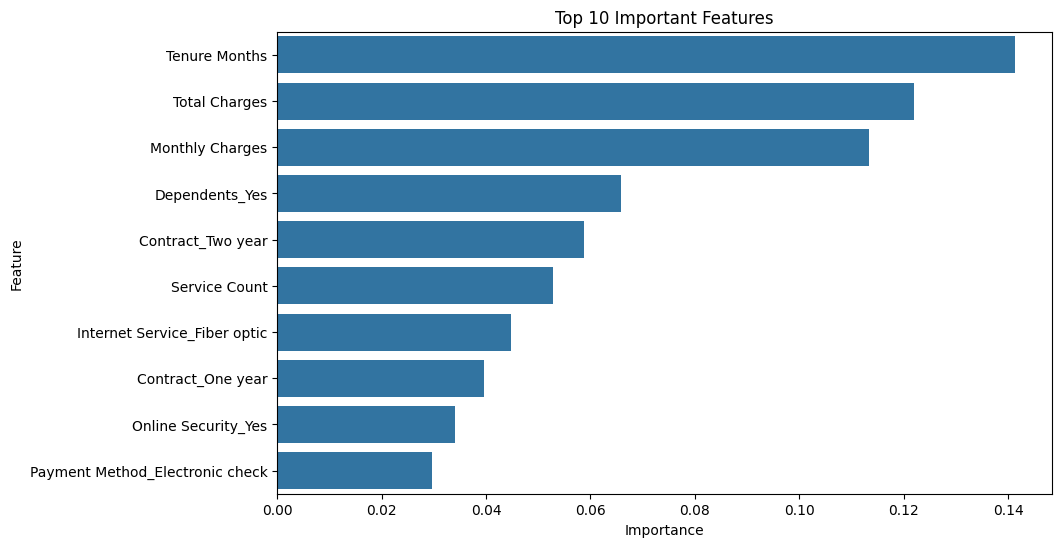

In [156]:
plt.figure(figsize=(10,6))

sns.barplot(data=importance.head(10),x="Importance",y="Feature")

plt.title("Top 10 Important Features")
plt.show()

### Key Drivers of Churn

-Tenure Months
- Total Charges
- Monthly Charges
- Dependents
- contract type

These variables have the strongest influence on customer churn prediction.

#Saving Model

In [157]:
import pickle

model_data = {"model": final_model,"scaler": scaler,
    "feature_names": X_train.columns.tolist()
}

with open("customer_churn_model.pkl", "wb") as f:
    pickle.dump(model_data, f)

print("Model saved successfully")

Model saved successfully


#Predicting Churn for a New Customer

In [158]:
#Load Saved Model
with open("customer_churn_model.pkl", "rb") as f:
    model_data = pickle.load(f)

loaded_model = model_data["model"]
scaler = model_data["scaler"]
feature_names = model_data["feature_names"]

In [159]:
def prepare_new_customer(df):

    # Tenure Group
    df["Tenure Group"] = pd.cut(df["Tenure Months"],bins=[-1,12,24,48,72],
        labels=["New","Growing","Established","Loyal"]
    )

    # Service Count
    service_cols = ["Phone Service","Multiple Lines","Online Security",
        "Online Backup","Device Protection","Tech Support","Streaming TV",
        "Streaming Movies"]

    df["Service Count"] = (df[service_cols].eq("Yes").sum(axis=1))

    # Auto Payment
    df["Auto Payment"] = (df["Payment Method"]
            .str.contains("automatic", case=False).astype(int) )



    replace_dict = {"No internet service": "No","No phone service": "No"}

    df = df.replace(replace_dict)

    df = pd.get_dummies(df,drop_first=True)

    df = df.reindex(columns=feature_names,fill_value=0)

    num_cols = ["Tenure Months","Monthly Charges","Total Charges",
                "Service Count"]

    df[num_cols] = scaler.transform(df[num_cols])

    return df

##Create New Customer Data

In [160]:
input_data = {
    "Gender": "Male",
    "Senior Citizen": "No",
    "Partner": "No",
    "Dependents": "No",
    "Tenure Months": 1,
    "Phone Service": "Yes",
    "Multiple Lines": "Yes",
    "Internet Service": "Fiber optic",
    "Online Security": "No",
    "Online Backup": "No",
    "Device Protection": "No",
    "Tech Support": "No",
    "Streaming TV": "Yes",
    "Streaming Movies": "Yes",
    "Contract": "Month-to-month",
    "Paperless Billing": "Yes",
    "Payment Method": "Electronic check",
    "Monthly Charges": 115.50,
    "Total Charges": 115.50
}

In [161]:
new_customer = pd.DataFrame([input_data])

In [162]:
new_customer = pd.DataFrame([input_data])

new_customer = prepare_new_customer( new_customer)

prediction = loaded_model.predict(new_customer)

probability = loaded_model.predict_proba(new_customer)[:,1]

print("Prediction:","Churn" if prediction[0] == 1 else "Stay")

print("Churn Probability:",round(probability[0] * 100, 2),"%")

Prediction: Churn
Churn Probability: 78.99 %
